C:\Users\Clement\AppData\Local\Temp\ipykernel_24008\2671218774.py:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\dvf_consolidated_dataset.csv', sep=',')


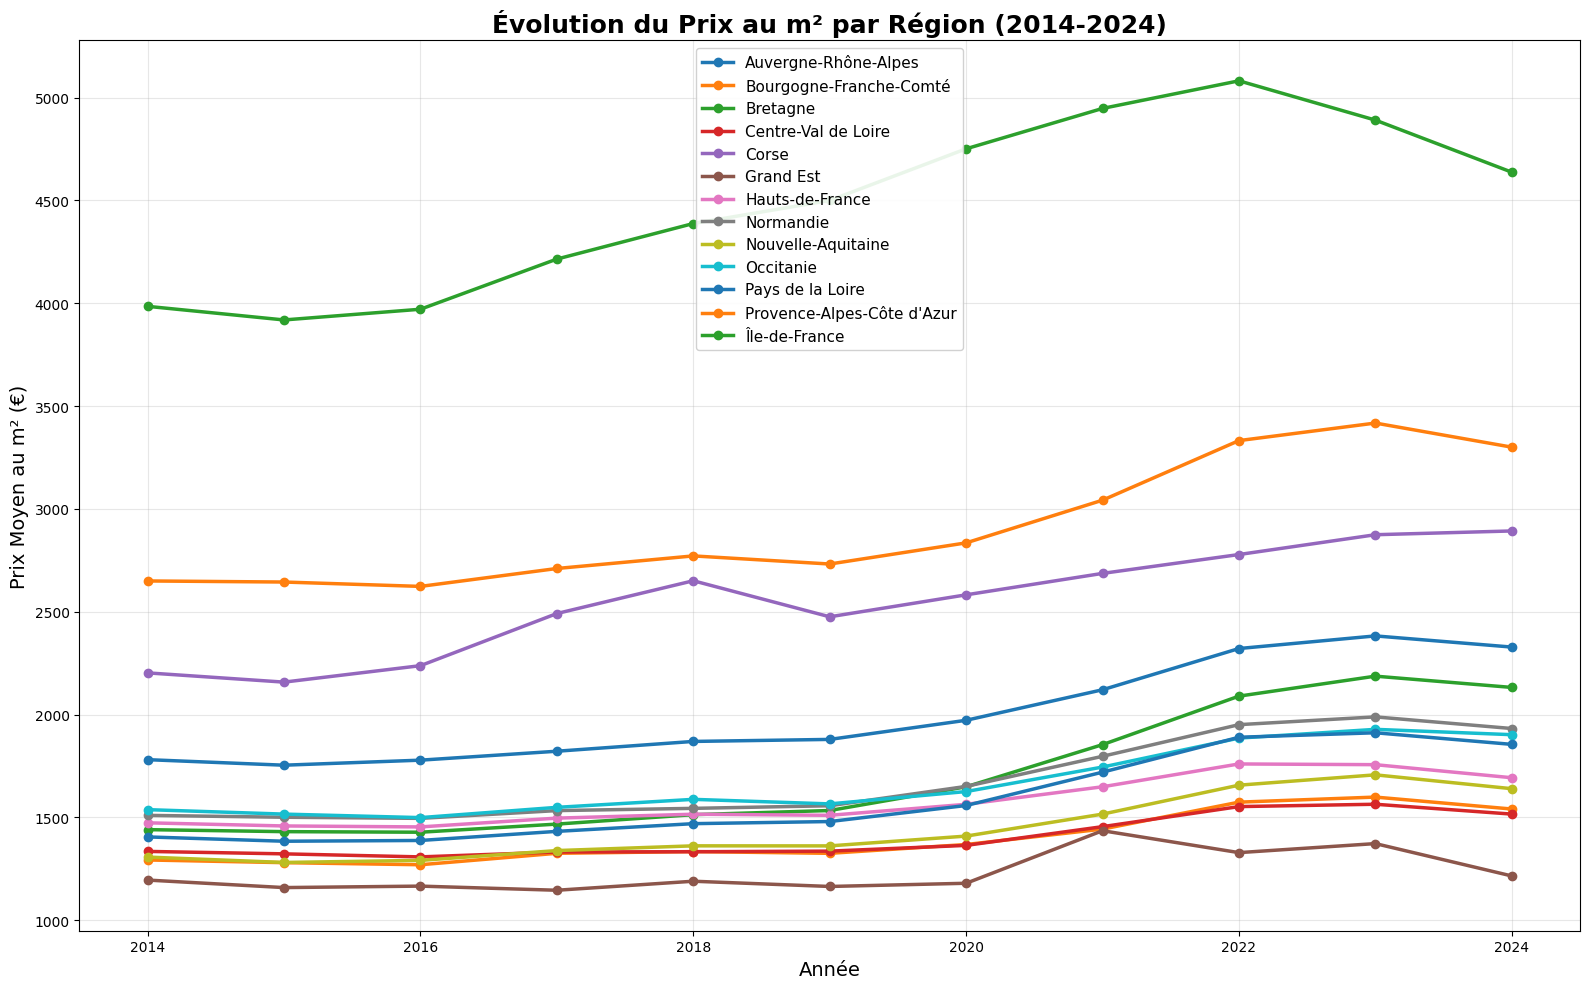

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire les données
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\dvf_consolidated_dataset.csv', sep=',')

# Nettoyer les noms de colonnes (supprimer les espaces)
df.columns = df.columns.str.strip()

# Extraire le code département (2 premiers chiffres du code INSEE)
df['Departement'] = df['INSEE_COM'].astype(str).str[:2]

# Dictionnaire des départements par région (France métropolitaine)
departements_regions = {
    'Auvergne-Rhône-Alpes': ['01', '03', '07', '15', '26', '38', '42', '43', '63', '69', '73', '74'],
    'Bourgogne-Franche-Comté': ['21', '25', '39', '58', '70', '71', '89', '90'],
    'Bretagne': ['22', '29', '35', '56'],
    'Centre-Val de Loire': ['18', '28', '36', '37', '41', '45'],
    'Corse': ['2A', '2B', '20'],
    'Grand Est': ['08', '10', '51', '52', '54', '55', '57', '67', '68', '88'],
    'Hauts-de-France': ['02', '59', '60', '62', '80'],
    'Île-de-France': ['75', '77', '78', '91', '92', '93', '94', '95'],
    'Normandie': ['14', '27', '50', '61', '76'],
    'Nouvelle-Aquitaine': ['16', '17', '19', '23', '24', '33', '40', '47', '64', '79', '86', '87'],
    'Occitanie': ['09', '11', '12', '30', '31', '32', '34', '46', '48', '65', '66', '81', '82'],
    'Pays de la Loire': ['44', '49', '53', '72', '85'],
    'Provence-Alpes-Côte d\'Azur': ['04', '05', '06', '13', '83', '84']
}

# ÉTAPE 1 : Calculer les moyennes par département et par année
moyennes_dept = df.groupby(['Departement', 'Annee']).agg({
    'Prixm2Moyen': 'mean'
}).reset_index()

# Créer un dictionnaire inversé : département -> région
dept_vers_region = {}
for region, depts in departements_regions.items():
    for dept in depts:
        dept_vers_region[dept] = region

# Ajouter la colonne région
moyennes_dept['Region'] = moyennes_dept['Departement'].map(dept_vers_region)

# Supprimer les départements sans région (DOM-TOM, etc.)
moyennes_dept = moyennes_dept[moyennes_dept['Region'].notna()]

# ÉTAPE 2 : Calculer la moyenne par région (moyenne des départements de chaque région)
moyennes_region = moyennes_dept.groupby(['Region', 'Annee']).agg({
    'Prixm2Moyen': 'mean'
}).reset_index()

# Créer le graphique
plt.figure(figsize=(16, 10))

# Tracer une ligne pour chaque région
for region in sorted(moyennes_region['Region'].unique()):
    data_region = moyennes_region[moyennes_region['Region'] == region]
    plt.plot(data_region['Annee'], data_region['Prixm2Moyen'], 
             marker='o', linewidth=2.5, label=region)

plt.title('Évolution du Prix au m² par Région (2014-2024)', fontsize=18, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Prix Moyen au m² (€)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

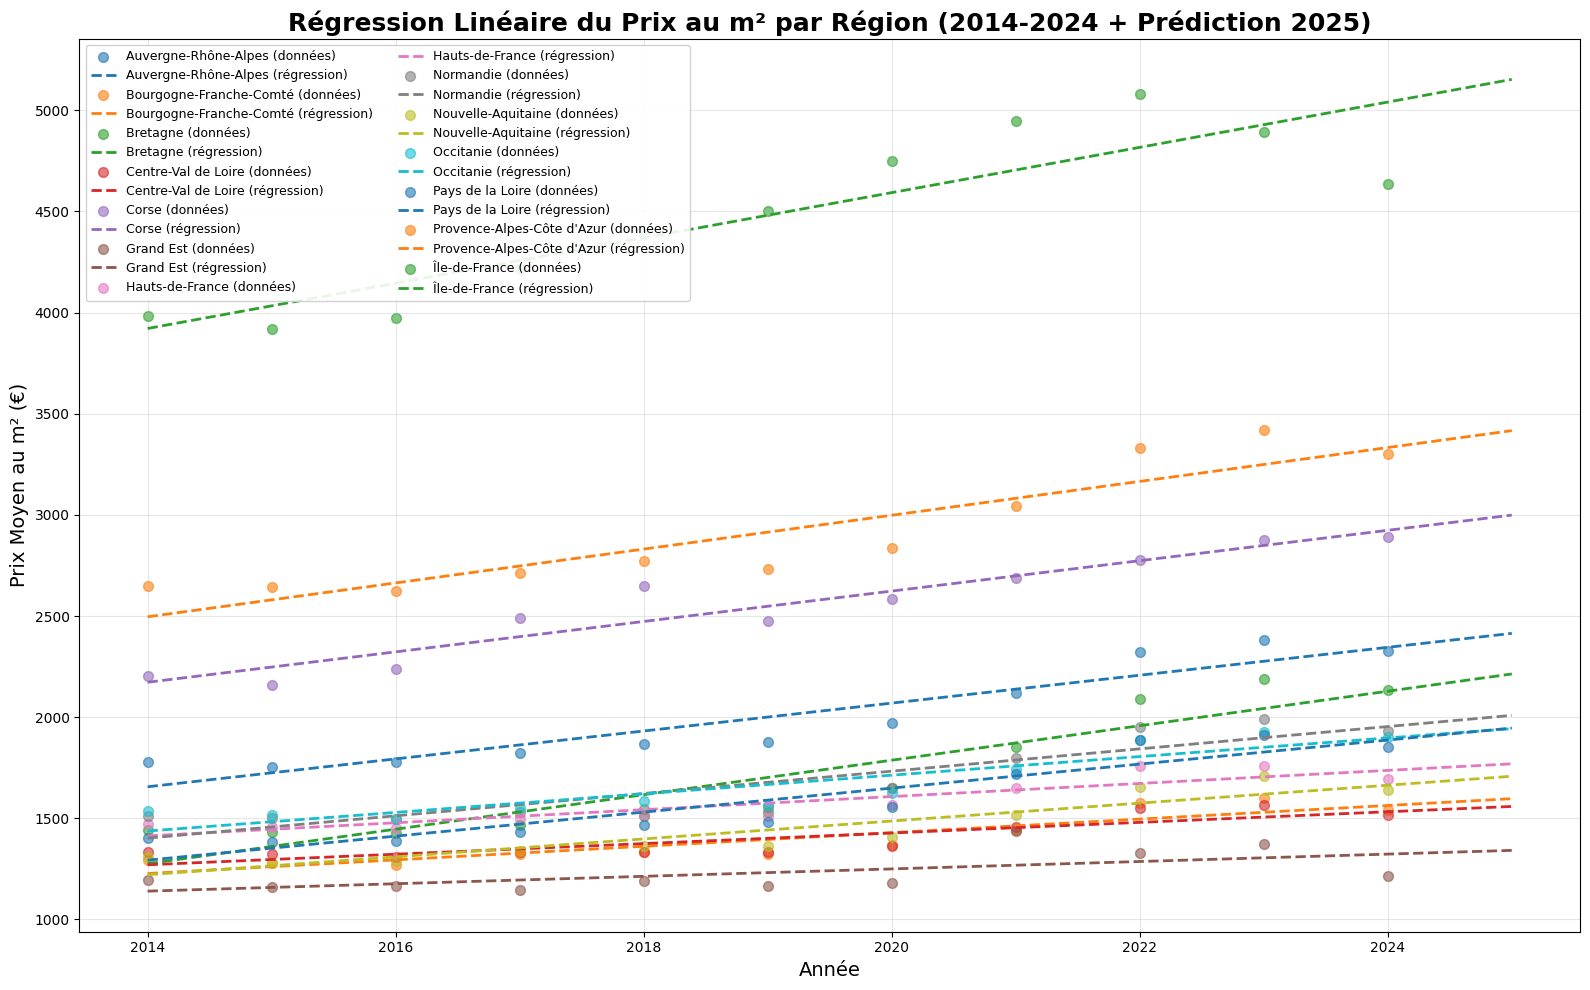


=== PRÉDICTIONS POUR 2025 (Régression Linéaire) ===
1. Île-de-France: 5152.29 €/m²
2. Provence-Alpes-Côte d'Azur: 3416.32 €/m²
3. Corse: 2998.80 €/m²
4. Auvergne-Rhône-Alpes: 2414.18 €/m²
5. Bretagne: 2213.53 €/m²
6. Normandie: 2008.82 €/m²
7. Pays de la Loire: 1946.25 €/m²
8. Occitanie: 1943.33 €/m²
9. Hauts-de-France: 1769.44 €/m²
10. Nouvelle-Aquitaine: 1707.89 €/m²
11. Bourgogne-Franche-Comté: 1597.11 €/m²
12. Centre-Val de Loire: 1558.65 €/m²
13. Grand Est: 1341.48 €/m²


In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Utiliser les données moyennes_region de la cellule précédente

# Créer un graphique pour les régressions linéaires
plt.figure(figsize=(16, 10))

# Dictionnaire pour stocker les prédictions
predictions_2025 = {}

# Pour chaque région, calculer la régression linéaire
for region in sorted(moyennes_region['Region'].unique()):
    # Filtrer les données pour cette région
    data_region = moyennes_region[moyennes_region['Region'] == region]
    
    # Préparer les données pour la régression
    X = data_region['Annee'].values.reshape(-1, 1)  # Années
    y = data_region['Prixm2Moyen'].values  # Prix au m²
    
    # Créer et entraîner le modèle de régression linéaire
    model = LinearRegression()
    model.fit(X, y)
    
    # Prédire pour les années existantes et 2025
    annees_prediction = np.arange(2014, 2026).reshape(-1, 1)
    prix_prediction = model.predict(annees_prediction)
    
    # Stocker la prédiction pour 2025
    predictions_2025[region] = prix_prediction[-1]
    
    # Tracer les données réelles
    plt.scatter(X, y, label=f'{region} (données)', alpha=0.6, s=50)
    
    # Tracer la ligne de régression
    plt.plot(annees_prediction, prix_prediction, linestyle='--', linewidth=2, 
             label=f'{region} (régression)')

plt.title('Régression Linéaire du Prix au m² par Région (2014-2024 + Prédiction 2025)', 
          fontsize=18, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Prix Moyen au m² (€)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)
plt.tight_layout()
plt.show()

# Afficher les prédictions pour 2025
print("\n=== PRÉDICTIONS POUR 2025 (Régression Linéaire) ===")
predictions_triees = sorted(predictions_2025.items(), key=lambda x: x[1], reverse=True)
for i, (region, prix) in enumerate(predictions_triees, 1):
    print(f"{i}. {region}: {prix:.2f} €/m²")

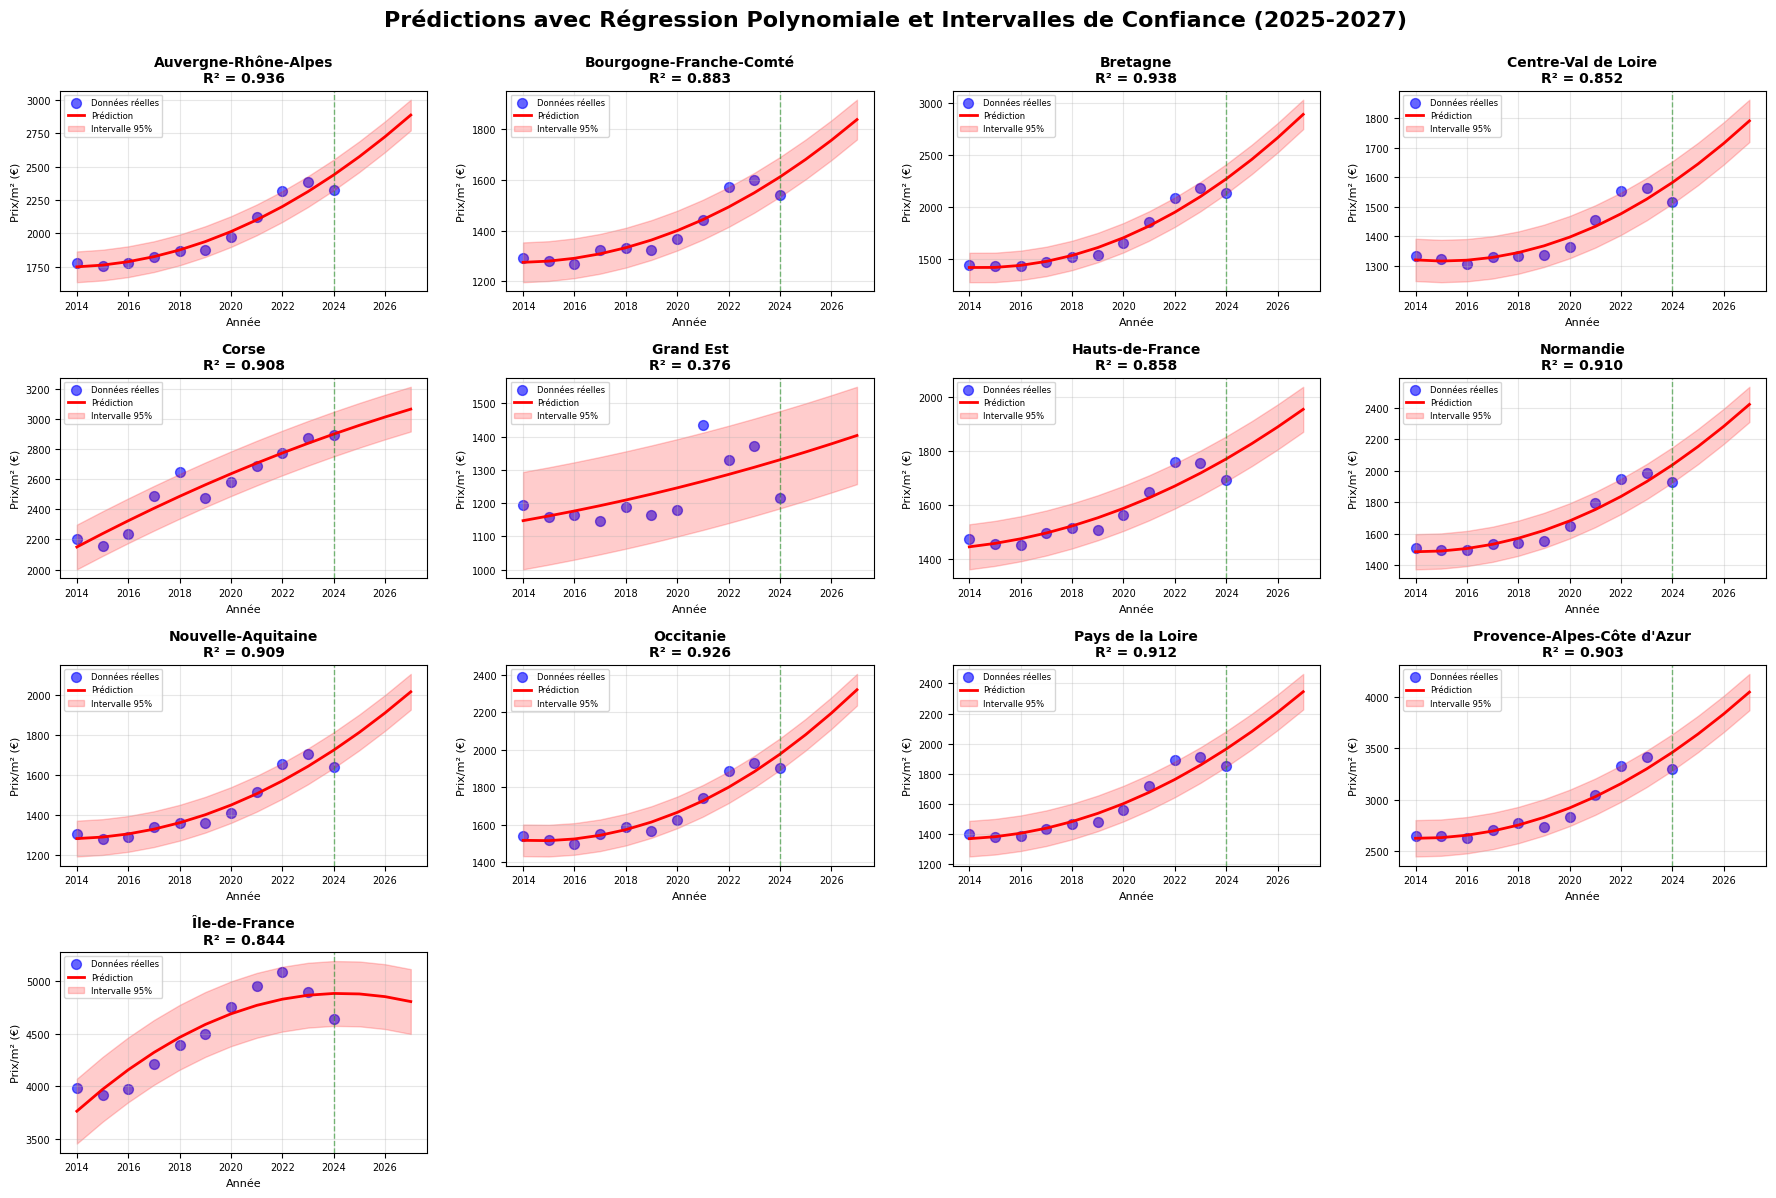


PRÉDICTIONS DU PRIX AU M² PAR RÉGION (2025-2027)
Région                         2025 (€/m²)     2026 (€/m²)     2027 (€/m²)     Incertitude (±) Qualité (R²)
----------------------------------------------------------------------------------------------------
Île-de-France                        4877            4851            4804      ±     308        0.844
Provence-Alpes-Côte d'Azur           3640            3835            4048      ±     177        0.903
Corse                                2959            3015            3067      ±     149        0.908
Auvergne-Rhône-Alpes                 2576            2726            2888      ±     115        0.936
Bretagne                             2458            2665            2891      ±     142        0.938
Normandie                            2155            2283            2423      ±     112        0.910
Occitanie                            2081            2196            2321      ±      85        0.926
Pays de la Loire           

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Utiliser les données de la cellule 1
plt.figure(figsize=(18, 12))

# Dictionnaire pour stocker les prédictions avec incertitudes
predictions_detaillees = {}

# Années futures à prédire
annees_futures = np.arange(2014, 2028).reshape(-1, 1)

for i, region in enumerate(sorted(moyennes_region['Region'].unique()), 1):
    # Filtrer les données pour cette région
    data_region = moyennes_region[moyennes_region['Region'] == region]
    
    X = data_region['Annee'].values.reshape(-1, 1)
    y = data_region['Prixm2Moyen'].values
    
    # ===== MODÈLE : Régression Polynomiale (degré 2) =====
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    # Prédictions
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    # Calculer l'écart-type des résidus pour l'intervalle de confiance
    y_pred_train = model_poly.predict(X_poly)
    residus = y - y_pred_train
    std_residus = np.std(residus)
    
    # Intervalle de confiance (95% = ±1.96 * std)
    marge_erreur = 1.96 * std_residus
    predictions_min = predictions_poly - marge_erreur
    predictions_max = predictions_poly + marge_erreur
    
    # Stocker les prédictions 2025-2027
    predictions_detaillees[region] = {
        '2025': predictions_poly[11],
        '2026': predictions_poly[12],
        '2027': predictions_poly[13],
        'incertitude': marge_erreur,
        'r2_score': r2_score(y, y_pred_train)
    }
    
    # ===== GRAPHIQUE PAR RÉGION =====
    plt.subplot(4, 4, i)
    
    # Données réelles
    plt.scatter(X, y, color='blue', s=50, alpha=0.6, label='Données réelles')
    
    # Ligne de régression polynomiale
    plt.plot(annees_futures, predictions_poly, 'r-', linewidth=2, label='Prédiction')
    
    # Intervalle de confiance
    plt.fill_between(annees_futures.flatten(), predictions_min, predictions_max, 
                     alpha=0.2, color='red', label='Intervalle 95%')
    
    # Marquer les années futures
    plt.axvline(x=2024, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.title(f'{region}\nR² = {predictions_detaillees[region]["r2_score"]:.3f}', 
              fontsize=10, fontweight='bold')
    plt.xlabel('Année', fontsize=8)
    plt.ylabel('Prix/m² (€)', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=6, loc='best')
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)

plt.suptitle('Prédictions avec Régression Polynomiale et Intervalles de Confiance (2025-2027)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ===== TABLEAU RÉCAPITULATIF DES PRÉDICTIONS =====
print("\n" + "="*100)
print("PRÉDICTIONS DU PRIX AU M² PAR RÉGION (2025-2027)")
print("="*100)
print(f"{'Région':<30} {'2025 (€/m²)':<15} {'2026 (€/m²)':<15} {'2027 (€/m²)':<15} {'Incertitude (±)':<15} {'Qualité (R²)':<12}")
print("-"*100)

predictions_triees = sorted(predictions_detaillees.items(), 
                           key=lambda x: x[1]['2025'], reverse=True)

for region, preds in predictions_triees:
    print(f"{region:<30} {preds['2025']:>10.0f}      {preds['2026']:>10.0f}      "
          f"{preds['2027']:>10.0f}      ±{preds['incertitude']:>8.0f}       {preds['r2_score']:>6.3f}")

print("="*100)
print("\n📊 INTERPRÉTATION :")
print("• R² proche de 1 = modèle très fiable")
print("• R² < 0.8 = forte volatilité, prédictions moins fiables")
print("• Incertitude = marge d'erreur à 95% de confiance")
print("• Les prédictions supposent une continuation des tendances passées")